# XP Exercises: Flower Classification using CNN

Week 10, Day 6

**What you will learn**
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots

**What you will create**: a CNN model that classifies 14 flower species. All parts form one continuous exercise.

## Dataset
Flower classification with 14 classes. Images are organized in class folders, with a provided `train` / `val` split.

The code below downloads the zip if it is not already present, extracts it and locates the dataset root automatically.

In [1]:
import os, sys, zipfile, shutil, glob, math, json, random, urllib.request
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide TensorFlow C++ info logs
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")
DATA_URL = ("https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/main/"
            "Week%206/W6D3/Flower%20Classification.zip")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Download the zip if needed (e.g. in a fresh Colab runtime)
if not DATA_ZIP.exists():
    print("Downloading dataset (~215 MB)...")
    urllib.request.urlretrieve(DATA_URL, DATA_ZIP)

# Extract once
marker = EXTRACT_DIR / ".extracted"
if not marker.exists():
    with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    marker.write_text("ok")
    print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
else:
    print("Already extracted. Skipping.")

# Find the dataset root: the folder that contains train/ and val/
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    names = [d.name.lower() for d in list_dirs(root)]
    if "train" in names and "val" in names:
        candidates.append(Path(root))
candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Already extracted. Skipping.
Candidate dataset roots: ['data/flower_data/Data']


## Part 1. Data exploration and visualization

> **Image size:** the original images are 256×256 up to 800×800 pixels. As suggested in the instructions, we resize them to **48×48** to keep training fast on a CPU (on a Colab GPU you can try 64×64 or 128×128 for better accuracy).

The provided `val` folder only has **98 images (7 per class)**: this is too small to compare many experiments reliably. So we:
- keep the provided `val` folder as a **final test set**, never used for tuning;
- split the `train` folder into **85% training / 15% validation** for model selection and early stopping.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (48, 48)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)

base = candidates[0]
train_dir = base / "train"
test_dir = base / "val"
print("Train dir:", train_dir, "| Test dir:", test_dir)

TensorFlow: 2.21.0
Train dir: data/flower_data/Data/train | Test dir: data/flower_data/Data/val


In [3]:
def load(directory, subset=None, image_size=IMG_SIZE, shuffle=True):
    kwargs = dict(validation_split=0.15, subset=subset) if subset else {}
    return tf.keras.utils.image_dataset_from_directory(
        directory, image_size=image_size, batch_size=None, seed=SEED, label_mode="int", shuffle=shuffle, **kwargs)

train_raw = load(train_dir, "training")
val_raw = load(train_dir, "validation")
test_raw = load(test_dir, shuffle=False)

class_names = train_raw.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch (images are kept unbatched so that we can change the batch size later)
train_raw, val_raw, test_raw = train_raw.cache(), val_raw.cache(), test_raw.cache()

def prepare(ds, batch_size=BATCH_SIZE, shuffle=False):
    if shuffle:
        ds = ds.shuffle(4000, seed=SEED)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = prepare(train_raw, shuffle=True)
val_ds = prepare(val_raw)
test_ds = prepare(test_raw)

Found 13642 files belonging to 14 classes.


Using 11596 files for training.


Found 13642 files belonging to 14 classes.


Using 2046 files for validation.


Found 98 files belonging to 14 classes.


Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


,train folder,val folder (test set)
astilbe,726,7
bellflower,872,7
black_eyed_susan,986,7
calendula,1011,7
california_poppy,1021,7
carnation,924,7
common_daisy,978,7
coreopsis,1035,7
dandelion,1038,7
iris,1041,7


Total: {'train folder': 13642, 'val folder (test set)': 98}


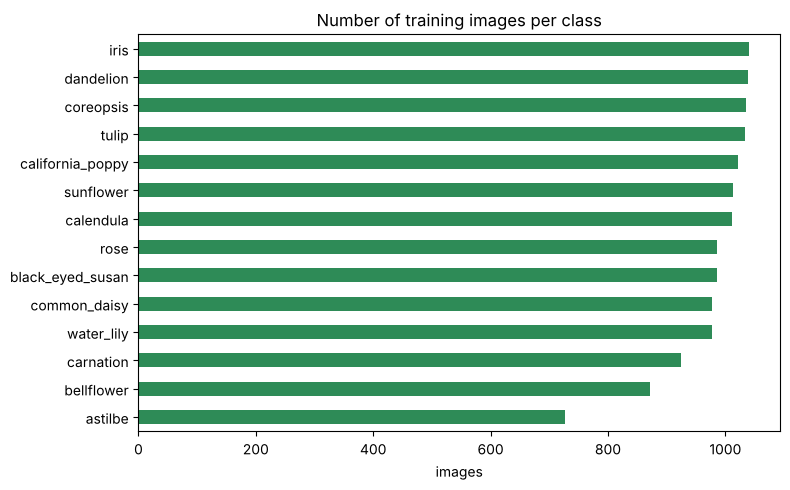

In [4]:
from collections import Counter

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        folder = Path(root) / cls
        counts[cls] = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif"})
    return counts

counts = pd.DataFrame({'train folder': count_images_per_class(train_dir), 'val folder (test set)': count_images_per_class(test_dir)})
display(counts)
print("Total:", counts.sum().to_dict())

counts['train folder'].sort_values().plot(kind='barh', figsize=(8, 5), color='seagreen')
plt.title('Number of training images per class')
plt.xlabel('images')
plt.tight_layout()
plt.show()

Found 13642 files belonging to 14 classes.


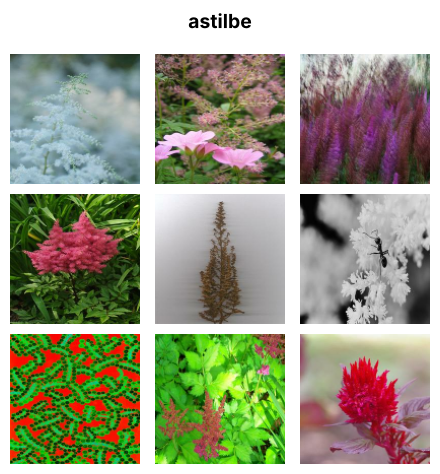

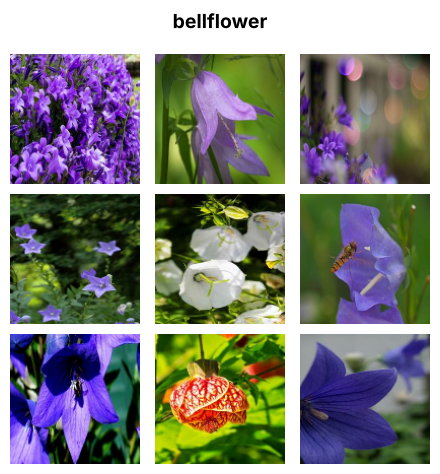

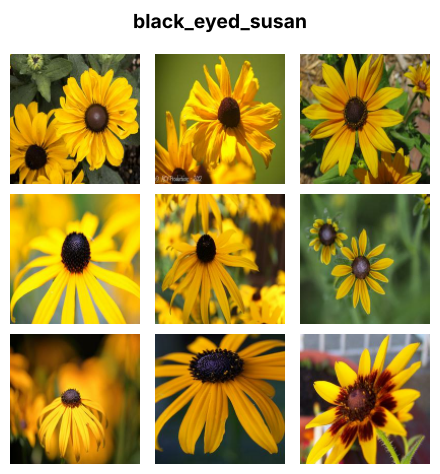

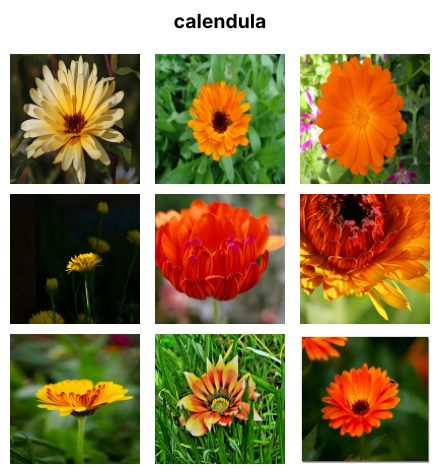

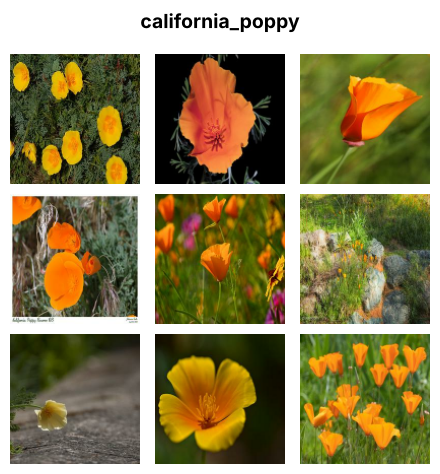

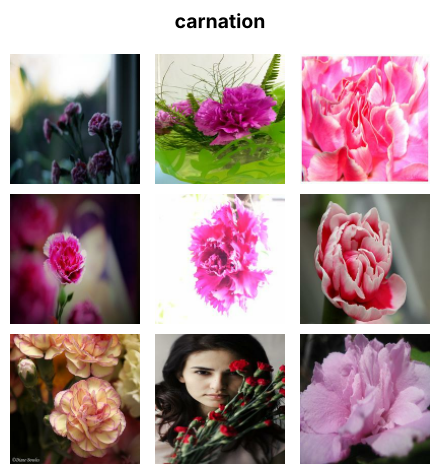

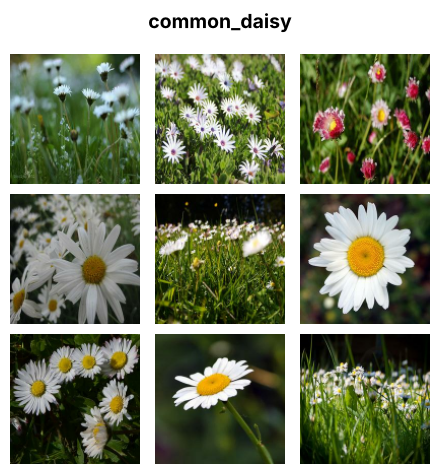

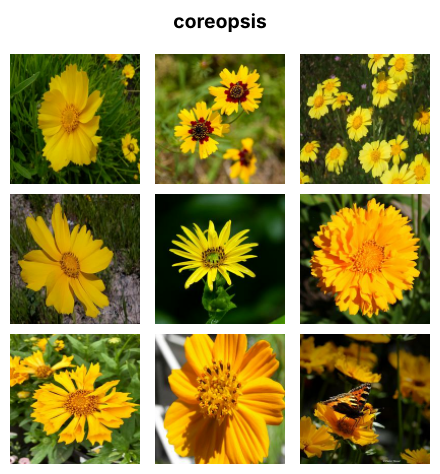

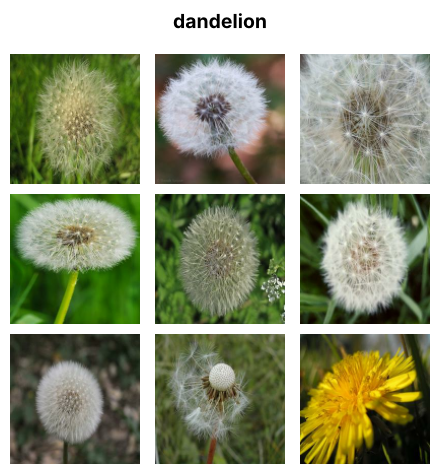

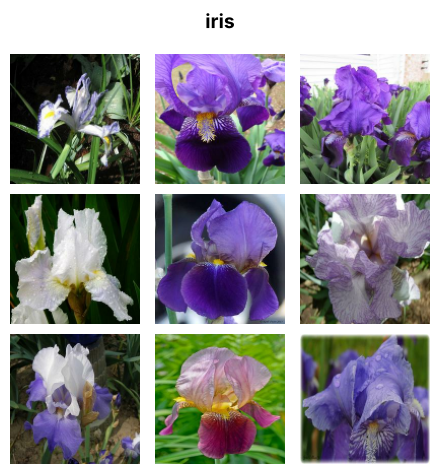

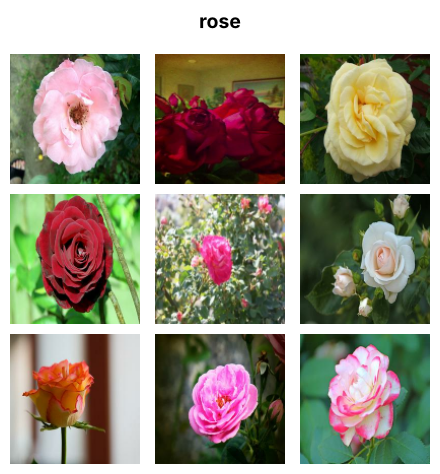

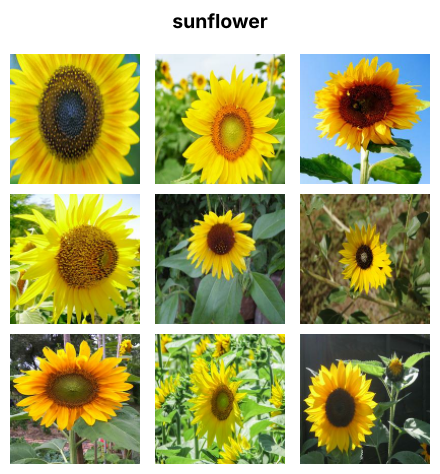

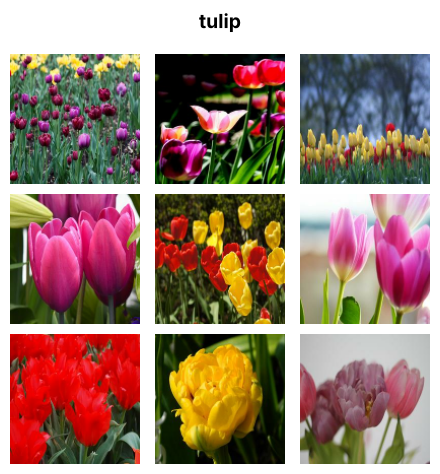

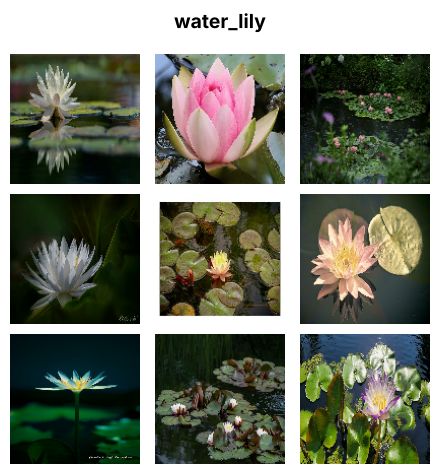

In [5]:
# Visualisation dataset at a higher resolution so the flowers are easier to see
viz_raw = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=(128, 128), batch_size=None, seed=SEED, shuffle=True)

def visualize_images(dataset, class_names, per_class=9):
    """Display one 3x3 grid of images for each class, with the class name as the grid title."""
    collected = {i: [] for i in range(len(class_names))}
    for img, label in dataset:
        l = int(label)
        if len(collected[l]) < per_class:
            collected[l].append(img.numpy().astype('uint8'))
        if all(len(v) == per_class for v in collected.values()):
            break
    for l, imgs in collected.items():
        fig, axes = plt.subplots(3, 3, figsize=(4.5, 4.8))
        for ax, im in zip(axes.ravel(), imgs):
            ax.imshow(im)
            ax.axis('off')
        fig.suptitle(class_names[l], fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

visualize_images(viz_raw, class_names)

**Dataset summary:** 13,642 training images and 98 test images (7 per class), 14 classes. The classes are fairly balanced: between 872 and 1,041 training images per class, except **astilbe** (726 images), the least represented class.

**Expected challenges:**
- **Similar colour palettes across species:** many flowers share the same colours: calendula, California poppy, coreopsis, black-eyed Susan, sunflower and dandelion are all yellow/orange; rose, carnation and tulip often have the same pink/red tones; bellflower, iris and some water lilies are purple. Colour alone is therefore not enough.
- **Similar shapes:** several species are "daisy-like" (a ring of petals around a centre: common daisy, coreopsis, black-eyed Susan, calendula), and roses and carnations both have dense, ruffled petals.
- **Intra-class variation:** the same species appears in many colours (roses and tulips can be red, pink, white or yellow), as a single flower in close-up or as a whole field, open or in bud, from the side or from above.
- **Background and lighting:** photos come from different sources, with grass, sky, pots, hands or text in the background, and very different lighting; the model may learn the background instead of the flower.
- **Low resolution:** at 48×48 pixels, fine details (petal edges, stamens, textures) disappear, which makes the similar species even harder to separate.
- **Class imbalance** is limited, but astilbe has about 30% fewer images than the other classes, and the test set is tiny (7 images per class), so each test error moves a class's score by 14 points.

**Learning point**
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.

## Part 2. Model architecture design

We start from the provided baseline, then design an improved variant, and train both in the same conditions (Adam, up to 15 epochs, early stopping on the validation loss).

In [6]:
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,006 (2.61 MB)

 Trainable params: 685,006 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
def conv_block(x, filters, kernel_size=3):
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return layers.MaxPooling2D()(x)

def build_variant(num_classes, dropout=0.4, optimizer="adam"):
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = layers.Rescaling(1./255)(inputs)
    x = conv_block(x, 32, kernel_size=5)   # 48 -> 24, larger 5x5 kernels in the first block
    x = conv_block(x, 64)                  # 24 -> 12
    x = conv_block(x, 128)                 # 12 -> 6
    x = conv_block(x, 256)                 # 6 -> 3
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs, name="flower_cnn_variant")
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model_variant = build_variant(num_classes)
model_variant.summary()

Model: "flower_cnn_variant"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             

 Total params: 461,550 (1.76 MB)

 Trainable params: 460,078 (1.76 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/15


363/363 - 11s - 30ms/step - accuracy: 0.3436 - loss: 1.8627 - val_accuracy: 0.4922 - val_loss: 1.4765


Epoch 2/15


363/363 - 7s - 19ms/step - accuracy: 0.5162 - loss: 1.4047 - val_accuracy: 0.5860 - val_loss: 1.2513


Epoch 3/15


...

363/363 - 7s - 19ms/step - accuracy: 0.8623 - loss: 0.3946 - val_accuracy: 0.6916 - val_loss: 1.0419


Epoch 12/15


363/363 - 7s - 18ms/step - accuracy: 0.8766 - loss: 0.3384 - val_accuracy: 0.7209 - val_loss: 1.0084


Epoch 13/15


363/363 - 6s - 17ms/step - accuracy: 0.8947 - loss: 0.2932 - val_accuracy: 0.7273 - val_loss: 1.0350


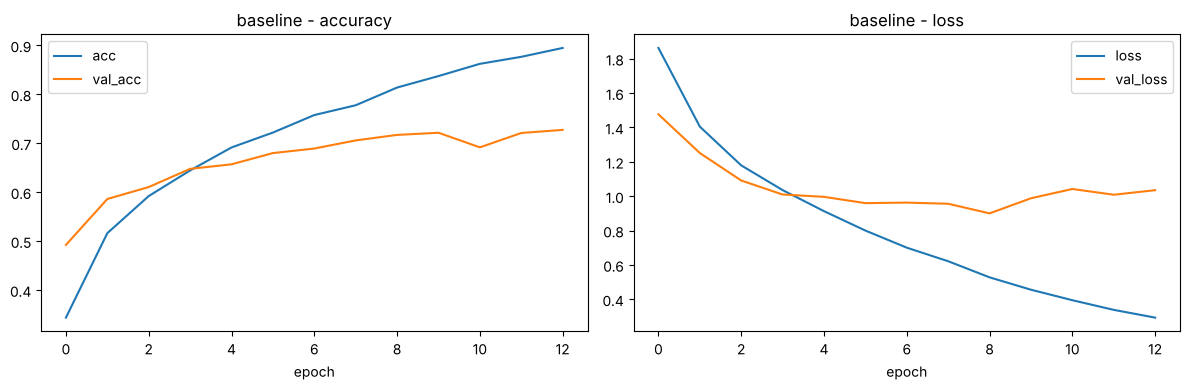

Epoch 1/15


363/363 - 17s - 46ms/step - accuracy: 0.4271 - loss: 1.7096 - val_accuracy: 0.2351 - val_loss: 2.6346


Epoch 2/15


363/363 - 14s - 39ms/step - accuracy: 0.5435 - loss: 1.3038 - val_accuracy: 0.4800 - val_loss: 1.6603


Epoch 3/15


...

363/363 - 21s - 57ms/step - accuracy: 0.8433 - loss: 0.4519 - val_accuracy: 0.6891 - val_loss: 1.0722


Epoch 11/15


363/363 - 15s - 40ms/step - accuracy: 0.8576 - loss: 0.4142 - val_accuracy: 0.6158 - val_loss: 1.4195


Epoch 12/15


363/363 - 15s - 40ms/step - accuracy: 0.8799 - loss: 0.3500 - val_accuracy: 0.6491 - val_loss: 1.2633


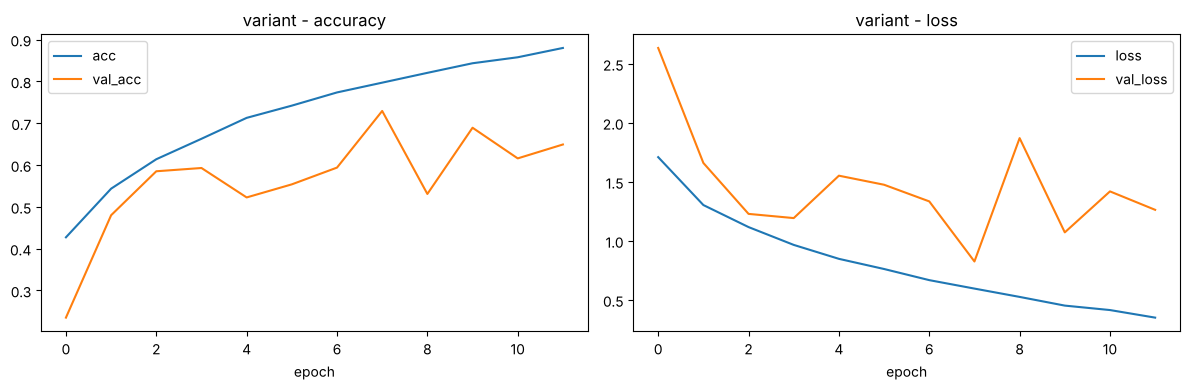

,params,epochs run,best val_acc,train acc at best epoch,time (s)
baseline,685006.0,13.0,0.727273,0.813815,91.0
variant,461550.0,12.0,0.729228,0.796913,182.0


In [8]:
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history.get("accuracy", []), label="acc")
    axes[0].plot(history.history.get("val_accuracy", []), label="val_acc")
    axes[0].set_title(f"{title} - accuracy"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history.history.get("loss", []), label="loss")
    axes[1].plot(history.history.get("val_loss", []), label="val_loss")
    axes[1].set_title(f"{title} - loss"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

def early_stop(patience=4):
    return tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

arch_results = {}
for name, builder in [("baseline", build_baseline), ("variant", build_variant)]:
    tf.keras.utils.set_random_seed(SEED)
    m = builder(num_classes)
    hist, dur = fit_model(m, train_ds, val_ds, epochs=15, callbacks=[early_stop()])
    plot_curves(hist, title=name)
    arch_results[name] = {"params": m.count_params(), "epochs run": len(hist.history["loss"]),
                          "best val_acc": max(hist.history["val_accuracy"]),
                          "train acc at best epoch": hist.history["accuracy"][int(np.argmin(hist.history["val_loss"]))],
                          "time (s)": round(dur)}
    if name == "variant":
        model_variant = m

display(pd.DataFrame(arch_results).T)

**Results:**

| Model | Parameters | Best val accuracy | Train accuracy at best epoch |
|---|---|---|---|
| Baseline (3 conv + Flatten + Dense 128) | 685,006 | 0.727 | 0.81 |
| Improved variant (4 conv blocks + BN + GAP) | 461,550 | 0.729 | 0.80 |

**Architectural choices and justification:**
- **4 convolutional blocks with progressively more filters (32 → 64 → 128 → 256):** each block halves the spatial size with max-pooling and doubles the number of filters. This makes the **receptive field grow** with depth: the first layers see small patches (edges, colours), the last ones see almost the whole flower (overall shape, petal arrangement), while keeping the computational cost per layer balanced.
- **5×5 kernels in the first block:** they capture slightly larger patterns (petal edges, textures) directly from the pixels; 3×3 kernels are enough afterwards, because the receptive field already grows through pooling.
- **Batch Normalization** after each convolution and after the dense layer normalises the activations, which **stabilises and speeds up training** and allows higher learning rates; the convolutions then don't need a bias (`use_bias=False`).
- **GlobalAveragePooling instead of Flatten:** it averages each feature map, which drastically reduces the number of parameters of the dense part (the variant has 33% fewer parameters than the baseline although it is deeper) and therefore the risk of overfitting.
- **Dense 256 + Dropout 0.4:** a compact classifier head; dropout randomly switches off 40% of the neurons during training, a **regularisation** that forces the network not to rely on a few features.

**Observations:** with the same default Adam settings, both models reach about **73% validation accuracy**. The baseline clearly **overfits**: its training accuracy keeps rising to 89% while its validation loss starts increasing after epoch 9. The variant learns as well with fewer parameters, but its validation curve is very **unstable** (between 52% and 73% from one epoch to the next): with Batch Normalization, the default learning rate is too aggressive here. This is what we tune in Part 3, and the variant is the model we keep for the next parts.

## Part 3. Hyperparameter tuning

We tune the improved architecture: optimizer (Adam, RMSprop, SGD with momentum), learning rate and batch size. Every run uses early stopping (patience 3, best weights restored) and at most 10 epochs. A learning-rate schedule (`ReduceLROnPlateau`) is added for the final training in Part 5.

In [9]:
def make_optimizer(name, lr):
    if name == "adam":
        return tf.keras.optimizers.Adam(lr)
    if name == "rmsprop":
        return tf.keras.optimizers.RMSprop(lr)
    return tf.keras.optimizers.SGD(lr, momentum=0.9, nesterov=True)

opts = [
    ("adam", 1e-3, 32, False),
    ("adam", 5e-4, 32, False),
    ("adam", 1e-3, 64, False),
    ("rmsprop", 1e-3, 32, False),
    ("sgd", 1e-2, 64, False),
]
results = []
histories = {}
for opt_name, lr, batch, schedule in opts:
    tf.keras.utils.set_random_seed(SEED)
    model = build_variant(num_classes, optimizer=make_optimizer(opt_name, lr))
    cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
    hist, dur = fit_model(model, prepare(train_raw, batch, shuffle=True), prepare(val_raw, batch), epochs=10, callbacks=cb)
    label = f"{opt_name} lr={lr} bs={batch}" + (" + LR schedule" if schedule else "")
    histories[label] = hist.history
    results.append({"opt": opt_name, "lr": lr, "batch": batch, "lr schedule": schedule,
                    "best_val_acc": float(max(hist.history["val_accuracy"])),
                    "best_val_loss": float(min(hist.history["val_loss"])),
                    "epochs": len(hist.history["loss"]), "time_s": round(dur, 1)})

results_df = pd.DataFrame(results).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
display(results_df)

Epoch 1/10


363/363 - 17s - 46ms/step - accuracy: 0.4126 - loss: 1.7366 - val_accuracy: 0.3905 - val_loss: 1.7665


Epoch 2/10


363/363 - 14s - 40ms/step - accuracy: 0.5467 - loss: 1.2993 - val_accuracy: 0.5244 - val_loss: 1.4152


Epoch 3/10


...

Epoch 6/10


182/182 - 13s - 70ms/step - accuracy: 0.7232 - loss: 0.7936 - val_accuracy: 0.4980 - val_loss: 1.5555


Epoch 7/10


182/182 - 13s - 70ms/step - accuracy: 0.7497 - loss: 0.7289 - val_accuracy: 0.4027 - val_loss: 2.2026


,opt,lr,batch,lr schedule,best_val_acc,best_val_loss,epochs,time_s
0,adam,0.0005,32,False,0.694526,0.978690,10,155.4
1,adam,0.0010,64,False,0.662757,1.086597,10,134.4
2,sgd,0.0100,64,False,0.571847,1.283168,7,90.9
3,adam,0.0010,32,False,0.561095,1.324683,6,89.7
4,rmsprop,0.0010,32,False,0.542033,1.431800,6,91.8


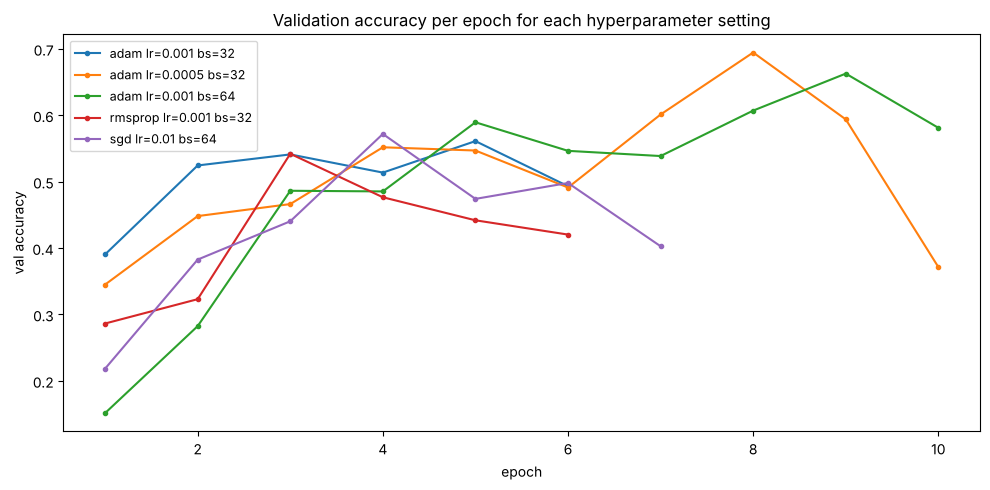

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, h in histories.items():
    ax.plot(range(1, len(h["val_accuracy"]) + 1), h["val_accuracy"], "o-", markersize=3, label=label)
ax.set_title("Validation accuracy per epoch for each hyperparameter setting")
ax.set_xlabel("epoch"); ax.set_ylabel("val accuracy"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Results (improved architecture, best validation accuracy):**

| Optimizer | Learning rate | Batch size | Best val accuracy | Epochs run |
|---|---|---|---|---|
| **Adam** | **5e-4** | **32** | **0.695** | 10 |
| Adam | 1e-3 | 64 | 0.663 | 10 |
| SGD (momentum 0.9, Nesterov) | 1e-2 | 64 | 0.572 | 7 |
| Adam | 1e-3 | 32 | 0.561 | 6 |
| RMSprop | 1e-3 | 32 | 0.542 | 6 |

**Best combination: Adam with a learning rate of 5e-4 and a batch size of 32.**

- A **smaller learning rate** (5e-4 instead of 1e-3) gives much smoother validation curves: the weights move in smaller steps, so the Batch Normalization statistics and the predictions on the validation set fluctuate less. Using a **larger batch** (64) has a similar stabilising effect, because the gradient estimate is less noisy, and comes second.
- **RMSprop** and **Adam at 1e-3 with batch 32** were the most unstable: their validation loss jumped up and down, so early stopping (patience 3) stopped them after only 6 epochs. Note that the same Adam 1e-3 setting reached 72.9% in Part 2 with one more epoch of patience: with such noisy curves, single short runs must be interpreted with caution.
- **SGD with momentum** is more stable but learns more slowly; it would need more epochs.
- **Learning rate scheduling** (`ReduceLROnPlateau`) is used in the final training (Part 5): every time the validation loss stops improving, the learning rate is halved. The final training curves show its effect: the validation accuracy jumps from ~66% to ~74–77% once the learning rate has been reduced. **Early stopping** with `restore_best_weights=True` keeps the best epoch instead of the last one.

## Part 4. Data augmentation

We use `ImageDataGenerator` as requested. To keep training fast, the training images (already resized to 48×48) are loaded once into memory and augmented on the fly with `datagen.flow(...)`; the validation set is the same as in the previous parts, so the results are directly comparable.

> Note: the model already contains a `Rescaling(1./255)` layer, so the generator must **not** rescale again (otherwise the pixels would be divided by 255 twice).

In-memory training set: (11596, 48, 48, 3) (11596,)


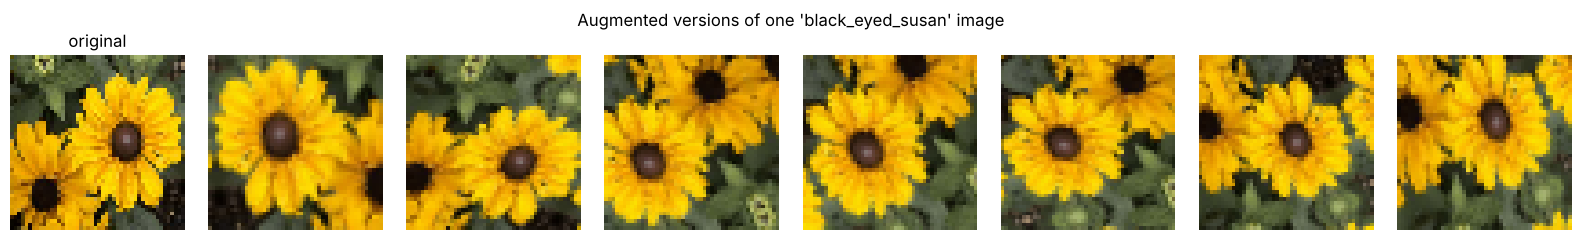

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

X_train = np.stack([x.numpy() for x, _ in train_raw]).astype("float32")
y_train = np.array([int(y) for _, y in train_raw])
print("In-memory training set:", X_train.shape, y_train.shape)

augmentations = {
    "no augmentation": dict(),
    "flip only": dict(horizontal_flip=True, vertical_flip=True),
    "rotation + flip": dict(rotation_range=30, horizontal_flip=True, vertical_flip=True),
    "zoom + shift + shear": dict(zoom_range=0.2, width_shift_range=0.1, height_shift_range=0.1, shear_range=0.1),
    "all combined": dict(rotation_range=30, horizontal_flip=True, vertical_flip=True, zoom_range=0.2,
                         width_shift_range=0.1, height_shift_range=0.1, shear_range=0.1, fill_mode="reflect"),
}

# Preview of the full augmentation on one image
datagen_preview = ImageDataGenerator(**augmentations["all combined"])
sample = X_train[:1]
fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
axes[0].imshow(sample[0].astype("uint8")); axes[0].set_title("original"); axes[0].axis("off")
for ax, batch in zip(axes[1:], datagen_preview.flow(sample, batch_size=1, seed=SEED)):
    ax.imshow(batch[0].astype("uint8")); ax.axis("off")
fig.suptitle(f"Augmented versions of one '{class_names[y_train[0]]}' image")
plt.tight_layout(); plt.show()

In [12]:
best = results_df.iloc[0]
print(f"Using the best hyperparameters from Part 3: {best['opt']} lr={best['lr']} batch={best['batch']}")

aug_results = {}
aug_histories = {}
for name, params in augmentations.items():
    tf.keras.utils.set_random_seed(SEED)
    datagen = ImageDataGenerator(**params)
    flow_train = datagen.flow(X_train, y_train, batch_size=int(best["batch"]), shuffle=True, seed=SEED)
    model_aug = build_variant(num_classes, optimizer=make_optimizer(best["opt"], float(best["lr"])))
    hist_aug, dur = fit_model(model_aug, flow_train, prepare(val_raw, int(best["batch"])), epochs=12,
                              callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)])
    aug_histories[name] = hist_aug.history
    i_best = int(np.argmin(hist_aug.history["val_loss"]))
    aug_results[name] = {"best val_acc": max(hist_aug.history["val_accuracy"]),
                         "train acc at best epoch": hist_aug.history["accuracy"][i_best],
                         "val acc at best epoch": hist_aug.history["val_accuracy"][i_best],
                         "epochs": len(hist_aug.history["loss"]), "time (s)": round(dur)}

aug_df = pd.DataFrame(aug_results).T
aug_df["overfitting gap"] = aug_df["train acc at best epoch"] - aug_df["val acc at best epoch"]
display(aug_df.sort_values("best val_acc", ascending=False))

Using the best hyperparameters from Part 3: adam lr=0.0005 batch=32


Epoch 1/12


363/363 - 18s - 50ms/step - accuracy: 0.4230 - loss: 1.7060 - val_accuracy: 0.3011 - val_loss: 2.1097


Epoch 2/12


363/363 - 15s - 42ms/step - accuracy: 0.5569 - loss: 1.2862 - val_accuracy: 0.4179 - val_loss: 1.9163


...

Epoch 11/12


363/363 - 16s - 44ms/step - accuracy: 0.7075 - loss: 0.8597 - val_accuracy: 0.6310 - val_loss: 1.0685


Epoch 12/12


363/363 - 16s - 44ms/step - accuracy: 0.7109 - loss: 0.8460 - val_accuracy: 0.6828 - val_loss: 0.9528


,best val_acc,train acc at best epoch,val acc at best epoch,epochs,time (s),overfitting gap
rotation + flip,0.699413,0.669800,0.699413,10.0,180.0,-0.029614
flip only,0.698925,0.716971,0.698925,11.0,186.0,0.018047
zoom + shift + shear,0.695503,0.759314,0.695503,12.0,197.0,0.063810
all combined,0.682796,0.710935,0.682796,12.0,192.0,0.028139
no augmentation,0.596774,0.621249,0.596774,6.0,94.0,0.024475


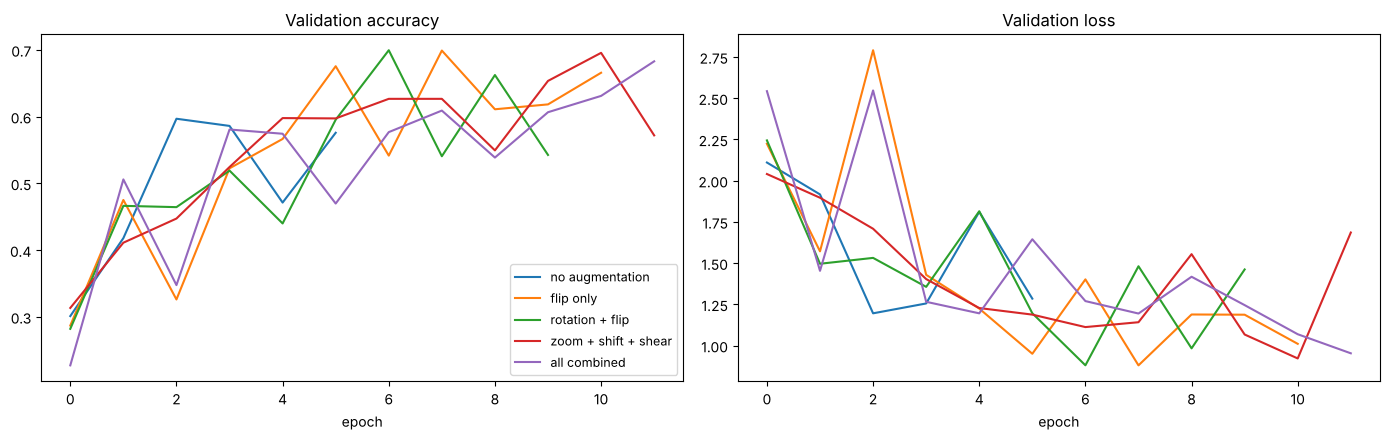

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, h in aug_histories.items():
    axes[0].plot(h["val_accuracy"], label=name)
    axes[1].plot(h["val_loss"], label=name)
axes[0].set_title("Validation accuracy"); axes[1].set_title("Validation loss")
for ax in axes: ax.set_xlabel("epoch")
axes[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

**Results (same model and hyperparameters, at most 12 epochs):**

| Augmentation | Best val accuracy |
|---|---|
| **Rotation (±30°) + horizontal/vertical flip** | **0.699** |
| Flip only | 0.699 |
| Zoom + shift + shear | 0.696 |
| All combined | 0.683 |
| No augmentation | 0.597 |

- **Every augmentation helps a lot**: about **+10 points** of validation accuracy compared with no augmentation (which also became unstable and was stopped after 6 epochs).
- **Rotation and flips are the most effective for this dataset**, because flowers have **no canonical orientation**: they are often photographed from above, and a sunflower rotated by 30° or mirrored is still a sunflower. These transformations create realistic new images without changing the label, and teach the model to recognise the flower whatever its orientation. With rotation + flip, the training accuracy is even slightly *below* the validation accuracy: the model cannot memorise the training images any more.
- **Zoom, shift and shear** simulate different framings and points of view (flower closer, off-centre, seen at an angle). They help almost as much, but leave a larger gap between training and validation accuracy (6 points).
- **All combined** is slightly behind within 12 epochs: the training images become much harder, so the model needs more epochs to learn. With a longer training it would probably catch up, but rotation + flip gives the best result for our budget, so it is the one we keep for the final model.

**Learning point**
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.

## Part 5. Performance evaluation and analysis

**Final model:** improved architecture + best hyperparameters + best augmentation, trained longer (up to 30 epochs) with early stopping and a `ReduceLROnPlateau` schedule.

Best augmentation: rotation + flip
Epoch 1/30


363/363 - 18s - 50ms/step - accuracy: 0.3986 - loss: 1.7780 - val_accuracy: 0.2820 - val_loss: 2.2439 - learning_rate: 5.0000e-04


Epoch 2/30


363/363 - 16s - 43ms/step - accuracy: 0.5190 - loss: 1.4105 - val_accuracy: 0.4663 - val_loss: 1.4958 - learning_rate: 5.0000e-04


Epoch 3/30


...

Epoch 28/30


363/363 - 16s - 44ms/step - accuracy: 0.8309 - loss: 0.5038 - val_accuracy: 0.7625 - val_loss: 0.6835 - learning_rate: 1.0000e-05


Epoch 29/30


363/363 - 16s - 43ms/step - accuracy: 0.8286 - loss: 0.5121 - val_accuracy: 0.7576 - val_loss: 0.6844 - learning_rate: 1.0000e-05


Training time: 7.9 min, epochs run: 29


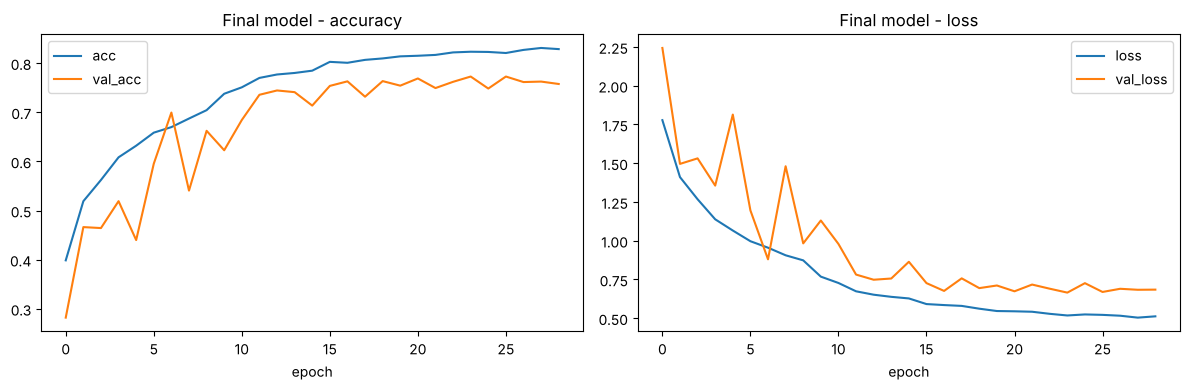

In [14]:
best_aug_name = aug_df["best val_acc"].idxmax()
print("Best augmentation:", best_aug_name)

tf.keras.utils.set_random_seed(SEED)
datagen = ImageDataGenerator(**augmentations[best_aug_name])
flow_train = datagen.flow(X_train, y_train, batch_size=int(best["batch"]), shuffle=True, seed=SEED)
best_model = build_variant(num_classes, optimizer=make_optimizer(best["opt"], float(best["lr"])))
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]
final_hist, final_dur = fit_model(best_model, flow_train, prepare(val_raw, int(best["batch"])), epochs=30, callbacks=callbacks)
print(f"Training time: {final_dur / 60:.1f} min, epochs run: {len(final_hist.history['loss'])}")
plot_curves(final_hist, title="Final model")

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels, title="Confusion matrix"):
    plt.figure(figsize=(9, 8))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.colorbar(fraction=0.046)
    plt.tight_layout()
    plt.show()

Validation split (15% of train)     loss = 0.6652 | accuracy = 0.7727
Test set (provided val folder)      loss = 0.6052 | accuracy = 0.8163



Classification report - validation split
                  precision    recall  f1-score   support

         astilbe      0.598     0.698     0.644        96
      bellflower      0.828     0.636     0.719       129
black_eyed_susan      0.852     0.947     0.897       152
       calendula      0.733     0.596     0.658       161
california_poppy      0.844     0.609     0.708       151
       carnation      0.548     0.606     0.575       142
    common_daisy      0.766     0.825     0.795       143
       coreopsis      0.766     0.817     0.791       164
       dandelion      0.903     0.824     0.862       159
            iris      0.894     0.894     0.894       141
            rose      0.746     0.671     0.707       140
       sunflower      0.907     0.929     0.918       168
           tulip      0.795     0.841     0.817       138
      water_lily      0.662     0.858     0.747       162

        accuracy                          0.773      2046
       macro avg      0.774 

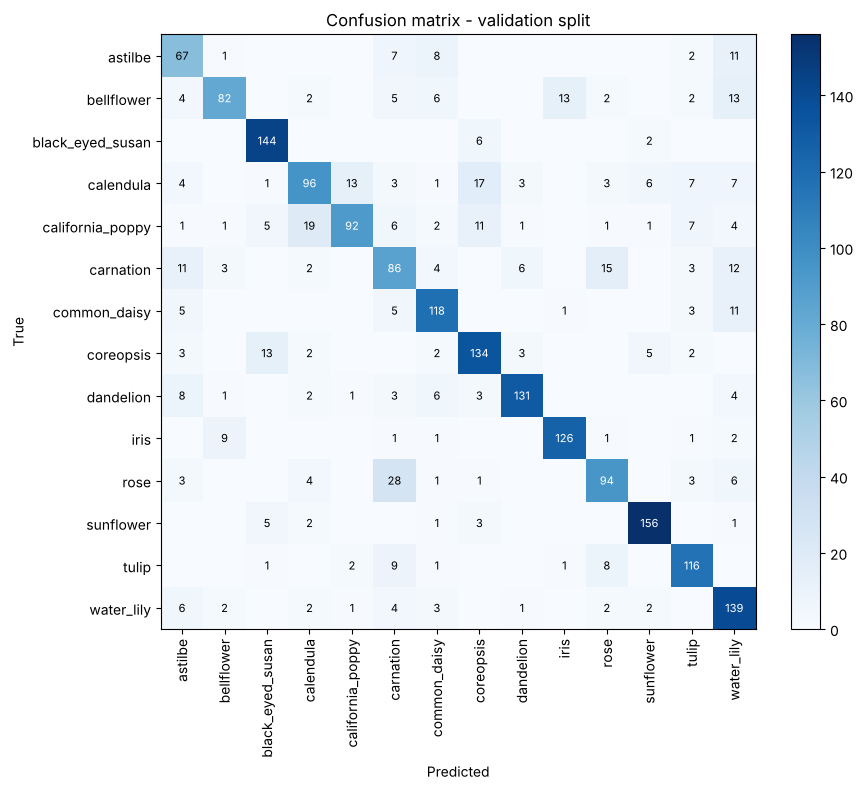

In [16]:
for name, ds in [("Validation split (15% of train)", val_ds), ("Test set (provided val folder)", test_ds)]:
    loss, acc = best_model.evaluate(ds, verbose=0)
    print(f"{name:<35} loss = {loss:.4f} | accuracy = {acc:.4f}")

# Detailed metrics on the validation split (~2,000 images, more reliable than the 98 test images)
y_true_v, y_pred_v, y_prob_v = collect_preds(best_model, val_ds)
print("\nClassification report - validation split")
print(classification_report(y_true_v, y_pred_v, target_names=class_names, digits=3))
plot_confusion(confusion_matrix(y_true_v, y_pred_v), class_names, "Confusion matrix - validation split")

Classification report - test set (98 images, 7 per class)
                  precision    recall  f1-score   support

         astilbe      0.857     0.857     0.857         7
      bellflower      0.875     1.000     0.933         7
black_eyed_susan      1.000     1.000     1.000         7
       calendula      0.750     0.857     0.800         7
california_poppy      1.000     0.571     0.727         7
       carnation      0.625     0.714     0.667         7
    common_daisy      0.667     0.857     0.750         7
       coreopsis      1.000     1.000     1.000         7
       dandelion      1.000     0.714     0.833         7
            iris      0.778     1.000     0.875         7
            rose      0.500     0.571     0.533         7
       sunflower      1.000     1.000     1.000         7
           tulip      1.000     0.571     0.727         7
      water_lily      0.714     0.714     0.714         7

        accuracy                          0.816        98
       macro

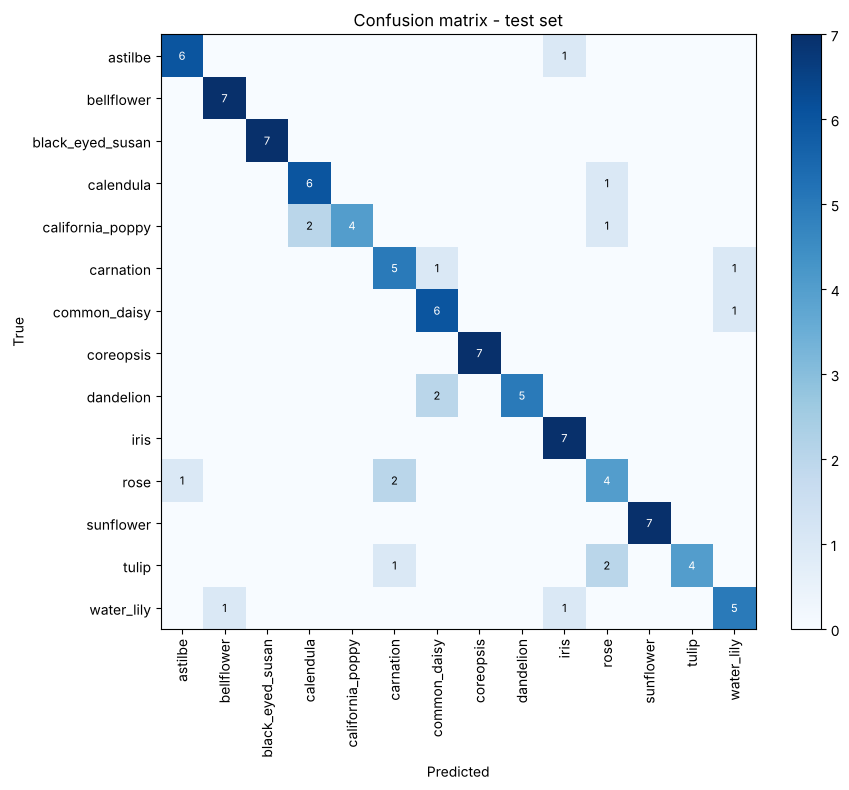

In [17]:
y_true_t, y_pred_t, y_prob_t = collect_preds(best_model, test_ds)
print("Classification report - test set (98 images, 7 per class)")
print(classification_report(y_true_t, y_pred_t, target_names=class_names, digits=3, zero_division=0))
plot_confusion(confusion_matrix(y_true_t, y_pred_t), class_names, "Confusion matrix - test set")

In [18]:
# Per-class difficulty and most frequent confusions (validation split)
cm_v = confusion_matrix(y_true_v, y_pred_v)
per_class = pd.DataFrame({"images": cm_v.sum(axis=1), "recall": np.diag(cm_v) / cm_v.sum(axis=1)}, index=class_names)
per_class = per_class.sort_values("recall")
display(per_class.style.format({"recall": "{:.1%}"}))

off = cm_v.copy(); np.fill_diagonal(off, 0)
pairs = sorted(((off[i, j], class_names[i], class_names[j]) for i in range(num_classes) for j in range(num_classes) if off[i, j] > 0), reverse=True)
print("Most frequent confusions (true -> predicted):")
for n, a, b in pairs[:8]:
    print(f"  {a} -> {b}: {n}")

,images,recall
calendula,161,59.6%
carnation,142,60.6%
california_poppy,151,60.9%
bellflower,129,63.6%
rose,140,67.1%
astilbe,96,69.8%
coreopsis,164,81.7%
dandelion,159,82.4%
common_daisy,143,82.5%
tulip,138,84.1%


Most frequent confusions (true -> predicted):
  rose -> carnation: 28
  california_poppy -> calendula: 19
  calendula -> coreopsis: 17
  carnation -> rose: 15
  coreopsis -> black_eyed_susan: 13
  calendula -> california_poppy: 13
  bellflower -> water_lily: 13
  bellflower -> iris: 13


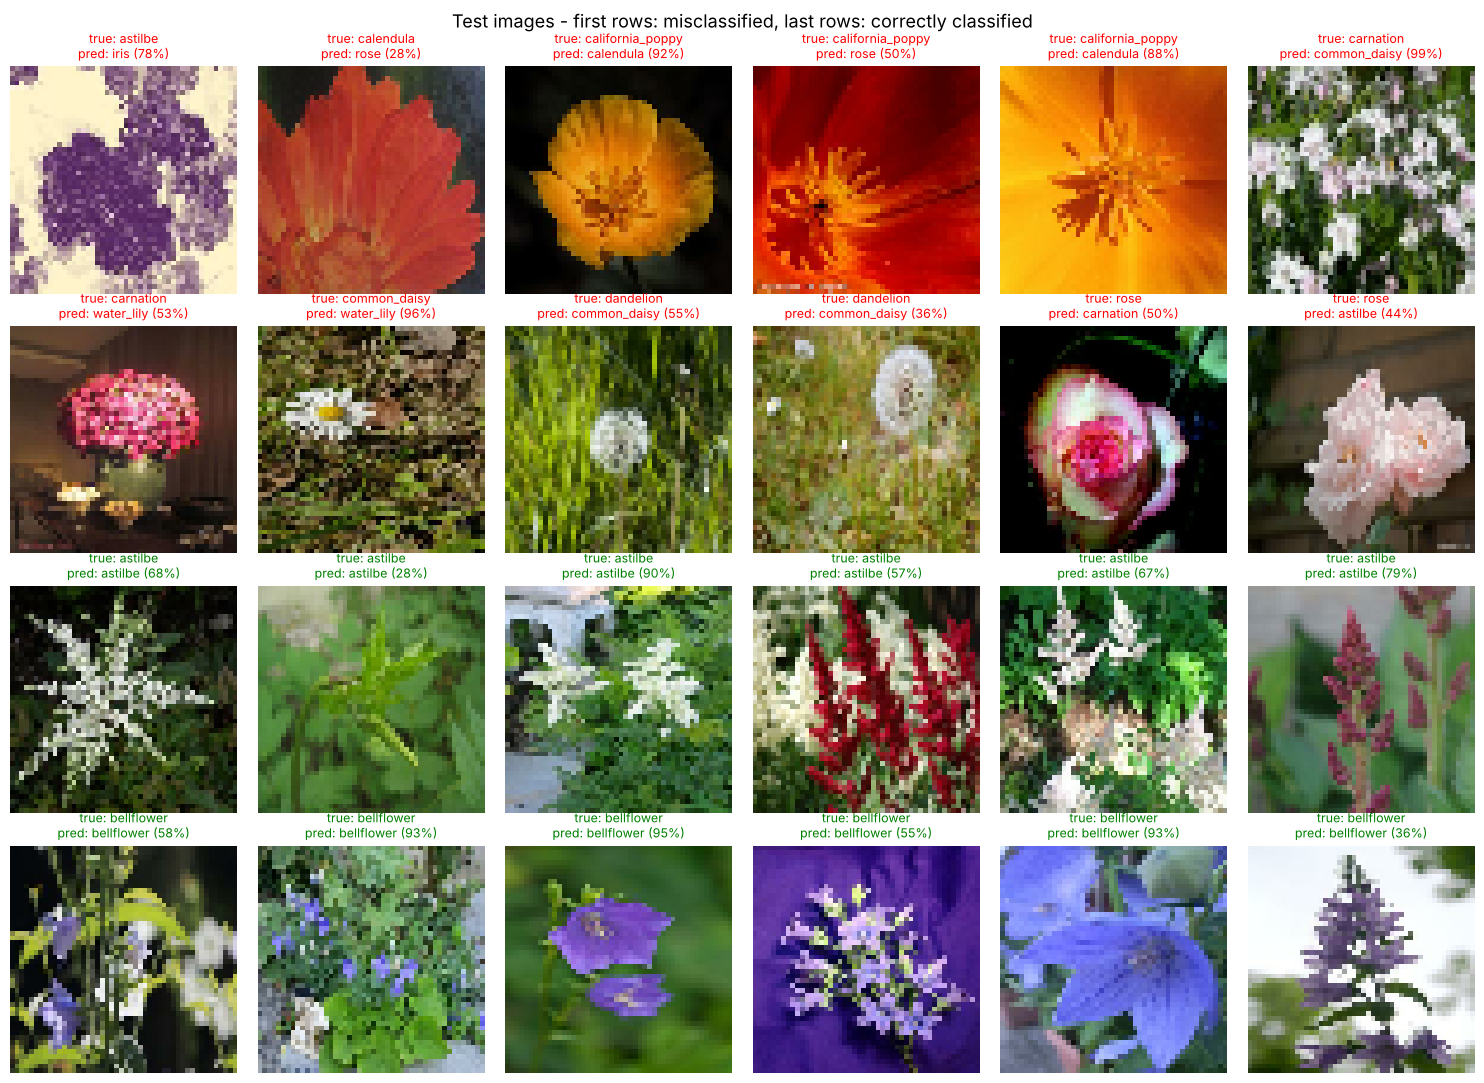

In [19]:
# Predictions on the test images: correct (green) and misclassified (red)
test_imgs = np.stack([x.numpy() for x, _ in test_raw]).astype("uint8")
order = list(np.where(y_pred_t != y_true_t)[0][:12]) + list(np.where(y_pred_t == y_true_t)[0][:12])
fig, axes = plt.subplots(4, 6, figsize=(15, 11))
for ax, k in zip(axes.ravel(), order):
    ax.imshow(test_imgs[k])
    ok = y_pred_t[k] == y_true_t[k]
    ax.set_title(f"true: {class_names[y_true_t[k]]}\npred: {class_names[y_pred_t[k]]} ({y_prob_t[k].max():.0%})",
                 color="green" if ok else "red", fontsize=9)
    ax.axis("off")
fig.suptitle("Test images - first rows: misclassified, last rows: correctly classified", fontsize=13)
plt.tight_layout()
plt.show()

**Learning curves:** the final model trained for 29 epochs. The training and validation curves rise together, and the validation loss keeps decreasing until the end, ending at about 83% training accuracy and 77% validation accuracy: the gap is small, so there is **no strong overfitting** (augmentation and dropout do their job). The big jumps of the validation accuracy happen each time `ReduceLROnPlateau` lowers the learning rate. Since the scores are still improving slowly, the model is rather slightly **underfitting**: a higher resolution, a larger model or more epochs would increase the accuracy.

**Overall performance:**
- Validation split (2,046 images): **77.3% accuracy**, macro F1 = 0.77.
- Test set (provided `val` folder, 98 images): **81.6% accuracy** (80 / 98), macro F1 = 0.82. With only 7 images per class, this score is less precise than the validation one (one image = 14 points for a class).

**Per-class performance (validation split):**
- **Easiest classes:** sunflower (F1 0.92), black-eyed Susan (0.90), iris (0.89) and dandelion (0.86). They have very distinctive shapes and colour patterns (a large yellow disc with a dark centre, the particular iris petals, the dandelion's fluffy yellow head).
- **Hardest classes:** carnation (F1 0.58), astilbe (0.64), calendula (0.66), rose (0.71) and California poppy (0.71). Calendula, California poppy and carnation also have the lowest recall (about 60%).

**Most frequent confusions and why they occur:**
- **rose ↔ carnation** (28 + 15 errors): both have dense, ruffled petals and the same pink/red/white colours; at 48×48 pixels the difference between their petal edges disappears.
- **California poppy ↔ calendula** (19 + 13) and **calendula → coreopsis** (17): all are bright orange/yellow flowers with similar round shapes.
- **coreopsis → black-eyed Susan** (13): both are yellow daisy-like flowers with a darker centre.
- **bellflower → iris / water lily** (13 + 13): violet and purple flowers.
- **Astilbe** is hard both because it has the fewest training images and because its feathery plumes look like a blurry texture at low resolution.

The misclassified test images shown above confirm this: most errors are between species of similar colour. The model is usually unsure when it is wrong: 12 of the 18 misclassified test images have a confidence below 60%, while the median confidence on correct predictions is 92%. A few errors are made with high confidence, typically between look-alike species such as rose and carnation.

**How to improve:** use a higher resolution (e.g. 128×128 on a GPU), train longer, and above all use **transfer learning** with a pre-trained network (MobileNetV2, EfficientNet), which already knows how to recognise fine textures and usually reaches more than 90% on this kind of dataset.

## Part 6. Model saving and deployment (optional)

In [20]:
os.makedirs("./data", exist_ok=True)
best_model.save("./data/flower_cnn.keras")  # native Keras format (recommended)
best_model.save("./data/flower_cnn.h5")     # legacy HDF5 file
print("Saved to ./data/:", [f for f in os.listdir("./data") if f.startswith("flower_cnn")])

# Check that the saved model gives the same predictions
reloaded = tf.keras.models.load_model("./data/flower_cnn.keras")
_, acc_reloaded = reloaded.evaluate(test_ds, verbose=0)
print(f"Reloaded model - test accuracy: {acc_reloaded:.4f}")

def predict_flower(path, model=reloaded):
    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    x = tf.keras.utils.img_to_array(img)[None, ...]
    probs = model.predict(x, verbose=0)[0]
    top = probs.argsort()[::-1][:3]
    return [(class_names[i], float(probs[i])) for i in top]

example = next((test_dir / "rose").glob("*.jpg"))
print("Top-3 prediction for", example.name, ":", predict_flower(example))

Saved to ./data/: ['flower_cnn.keras', 'flower_cnn.h5']


Reloaded model - test accuracy: 0.8163
Top-3 prediction for 4373364544_ef9509ae1b_c.jpg : [('rose', 0.5543337464332581), ('carnation', 0.3836313486099243), ('water_lily', 0.053435683250427246)]


**Deployment options:**

- **Web API with Flask:** load the saved `.keras` model once at start-up and expose an endpoint that receives an image and returns the predicted species:

```python
from flask import Flask, request, jsonify
import tensorflow as tf, numpy as np, io
from PIL import Image

app = Flask(__name__)
model = tf.keras.models.load_model("flower_cnn.keras")
CLASS_NAMES = [...]  # same order as during training

@app.route("/predict", methods=["POST"])
def predict():
    img = Image.open(io.BytesIO(request.files["image"].read())).convert("RGB").resize((48, 48))
    probs = model.predict(np.array(img, dtype="float32")[None, ...], verbose=0)[0]
    return jsonify({"species": CLASS_NAMES[int(probs.argmax())], "confidence": float(probs.max())})
```

- **Cloud:** package this API in a Docker container and deploy it on Google Cloud Run, AWS (SageMaker endpoint or Lambda) or Azure, or serve the SavedModel with TensorFlow Serving / Vertex AI.
- **Mobile:** convert the model to **TensorFlow Lite** (`tf.lite.TFLiteConverter.from_keras_model(best_model)`) to run predictions directly on a phone, even offline, e.g. in a "which flower is this?" camera app.